In [232]:
%matplotlib inline
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_context('notebook')

import os

os.getcwd()

'C:\\Users\\nasakyi\\Desktop\\Thesis'

In [233]:
Data1 = pd.read_csv('C:/Users/nasakyi/Desktop/Thesis/VaccTrain.csv')
Data1.head

<bound method NDFrame.head of      VaccManDat.VACC_STATUS  VaccManDat.GENDER  XG1  XG2  VaccManDat.RACE  \
0                         0                  1    1    0                1   
1                         1                  2    0    1                2   
2                         0                  1    1    0                4   
3                         0                  1    1    0                1   
4                         0                  1    1    0                1   
..                      ...                ...  ...  ...              ...   
794                       0                  1    1    0                3   
795                       0                  2    0    1                1   
796                       0                  2    0    1                1   
797                       1                  2    0    1                1   
798                       0                  2    0    1                1   

     VaccManDat.HISPANIC  VaccManDat.EDUC  XE

In [234]:
X = Data1[['XG1','XE1', 'XE2', 'XE3','XIN1','XIN2']]
X.head()

,XG1,XE1,XE2,XE3,XIN1,XIN2
0,1,0,0,0,0,0
1,0,0,1,0,1,0
2,1,0,0,0,0,1
3,1,0,0,0,0,0
4,1,0,0,0,0,0


In [235]:
# Outputting the binary response vector, VaccManDat.VACC_STATUS

vacc = Data1.iloc[:,0]
print(vacc)

0      0
1      1
2      0
3      0
4      0
      ..
794    0
795    0
796    0
797    1
798    0
Name: VaccManDat.VACC_STATUS, Length: 799, dtype: int64


In [236]:
reg = Data1.iloc[:,17].astype('category')
print(reg)

0      1
1      1
2      1
3      1
4      1
      ..
794    8
795    8
796    8
797    8
798    8
Name: REGCODE, Length: 799, dtype: category
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]


In [237]:
# Model IV: Both varying Slopes and Varying Intercepts on the Basis of Regions

In [8]:
import pystan

mod4_code = """     

data {
  int<lower=0> J;               //the number of regions
  int<lower=0> N;               //the number of observations    
  int<lower=0> K;               //the number of features/covariates  
  int<lower=1,upper=J> Z[N];    //group level predictor (regional codes)
  matrix[N,K] X;                  //the model (features/covariates) matrix
  
  int y[N];                     //the response     
}


parameters {
  vector[J] alpha;
  //real alpha;                 //intercept
  matrix[K,J] beta;            //the regression coefficients                                                        

} 

transformed parameters {                                                                             
  vector[N] lpred; 
  vector[N] pi_hat;
  //linpred = alpha+X*beta[Z];   // logit=P(y=1)=pi  
  
  for (i in 1:N) {
      lpred[i] = alpha[Z[i]] + X[i] * beta[:,Z[i]];
      pi_hat[i] = exp(lpred[i])/(1 + exp(lpred[i])); 
  }
}


model {

   //--------------priors----------------------------
  alpha ~ cauchy(0,10);       //prior for the intercept following Gelman 2008                              
                                                                                                     
  for(j in 1:K)               // K=1, if one regressor                                                                                   
    beta[j] ~ student_t(1, 0, 0.03);                                                                 
    

 //------------likelihood-----------                                                 
  //y ~ bernoulli_logit(alpha+X*beta[Z]);
  y ~ bernoulli_logit(lpred);

}


"""

In [9]:
mod4_data = {
    'J':len(pd.unique(Data1['REGCODE'])),
    'N':len(vacc),
    'K':6,
    'X':X, # Based on Education Level 1
    'y':vacc,
    'Z':reg, # Stan counts starting at 1
}

print(mod4_data)

{'J': 8, 'N': 799, 'K': 6, 'X':      XG1  XE1  XE2  XE3  XIN1  XIN2
0      1    0    0    0     0     0
1      0    0    1    0     1     0
2      1    0    0    0     0     1
3      1    0    0    0     0     0
4      1    0    0    0     0     0
..   ...  ...  ...  ...   ...   ...
794    1    0    0    1     0     1
795    0    0    0    1     0     0
796    0    0    0    1     0     1
797    0    0    0    1     0     1
798    0    0    1    0     1     0

[799 rows x 6 columns], 'y': 0      0
1      1
2      0
3      0
4      0
      ..
794    0
795    0
796    0
797    1
798    0
Name: VaccManDat.VACC_STATUS, Length: 799, dtype: int64, 'Z': 0      1
1      1
2      1
3      1
4      1
      ..
794    8
795    8
796    8
797    8
798    8
Name: REGCODE, Length: 799, dtype: category
Categories (8, int64): [1, 2, 3, 4, 5, 6, 7, 8]}


In [10]:
SM_m4 = pystan.StanModel(model_code = mod4_code)

INFO:pystan:COMPILING THE C++ CODE FOR MODEL anon_model_122e968f72321a4cf2cf90e6286c0235 NOW.


In [11]:
fit_m4 = SM_m4.sampling(data = mod4_data, iter=1000, seed=1234)

To run all diagnostics call pystan.check_hmc_diagnostics(fit)


In [12]:
print(fit_m4)

Inference for Stan model: anon_model_122e968f72321a4cf2cf90e6286c0235.
4 chains, each with iter=1000; warmup=500; thin=1; 
post-warmup draws per chain=500, total post-warmup draws=2000.

               mean se_mean     sd   2.5%    25%     50%    75%  97.5%  n_eff   Rhat
alpha[1]       -1.5  9.4e-3   0.26  -2.08  -1.65   -1.48  -1.32  -1.04    787    1.0
alpha[2]      -2.49  8.6e-3   0.32  -3.19  -2.69   -2.47  -2.27  -1.91   1382    1.0
alpha[3]      -2.09    0.01   0.34  -2.84   -2.3   -2.07  -1.87  -1.49    841    1.0
alpha[4]      -1.77  7.9e-3    0.3  -2.39  -1.96   -1.76  -1.56  -1.21   1440    1.0
alpha[5]      -1.82  8.8e-3   0.35  -2.54  -2.05   -1.82  -1.59  -1.16   1624    1.0
alpha[6]      -2.22    0.01   0.42  -3.16  -2.46    -2.2  -1.93  -1.47   1610    1.0
alpha[7]      -2.54    0.02    0.5  -3.65  -2.82   -2.48  -2.18  -1.74    423    1.0
alpha[8]      -2.16    0.01   0.51  -3.27  -2.48   -2.12  -1.81  -1.26   1708    1.0
beta[1,1]   -2.1e-3  2.9e-3   0.11  -0.24  -0.03

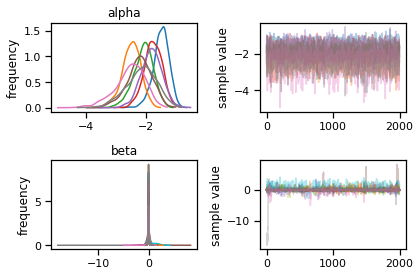

In [13]:
fit_m4.plot(pars=['alpha', 'beta'])
plt.tight_layout()

In [240]:
region = Data1['REGCODE'].unique()
reg_sort = [1,2,3,4,5,6,7,8]
mod4_alpha = fit_m4['alpha'].mean(axis=0)
mod4_beta = fit_m4['beta'].mean(axis=0)
xvals = ["Gender", "Edu 1", "Edu 2", "Edu 3", "Inc 1", "Inc 2"]
odds_ratio4 = np.exp(mod4_beta)
delta_odds4 = odds_ratio4 - 1
delta_odds4

array([[-0.00207297,  0.02718257, -0.01093968, -0.06777841, -0.08852788,
         0.01554278, -0.04690182, -0.02403111],
       [ 0.00311463, -0.17106985,  0.00361441, -0.02457131,  0.13976367,
         0.00419069,  0.02126302, -0.00781934],
       [ 0.05698846,  0.01171897,  0.05194623,  0.10502513, -0.07431741,
        -0.00433569,  0.1021549 , -0.00648115],
       [ 0.12805656,  0.03282293, -0.00174309,  0.04586356,  0.00583914,
         0.04674907,  0.9314866 ,  0.03020662],
       [ 0.03881041,  0.01247194,  0.01483043,  0.02011701,  0.06352678,
        -0.01628856,  0.05697042, -0.0331375 ],
       [ 0.0192773 ,  0.00905318,  0.14781213,  0.00346529, -0.00802267,
         0.01032098,  0.08765888,  0.00677875]])

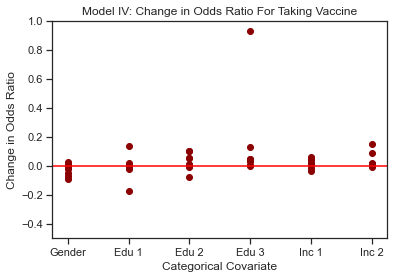

In [241]:
# Plot of Change in Odds Ratios against Predictors: Model Iv

plt.plot(xvals, delta_odds4,'o', label="Change in Odds Ratio", color='darkred')
plt.ylim(-0.5, 1)
plt.axhline(y=0, color='red', label="Midline")
#plt.legend(loc="upper left")
plt.title("Model IV: Change in Odds Ratio For Taking Vaccine")
plt.xlabel("Categorical Covariate")
plt.ylabel("Change in Odds Ratio")
plt.show()

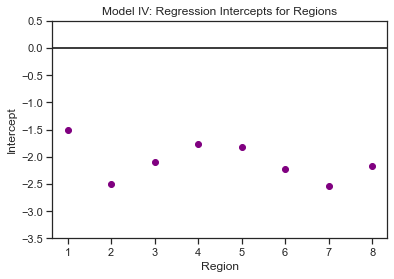

In [242]:
# Plot of Intercepts Against Regions: Model IV
plt.plot(region,mod4_alpha,'o',color='purple')
plt.axhline(y=0,color='black')
plt.xlabel("Region")
plt.ylabel("Intercept")
plt.ylim(-3.5, 0.5)
#plt.legend(loc='upper right', [Data1['REGION'].unique])
plt.title("Model IV: Regression Intercepts for Regions")
plt.show()

<AxesSubplot:>

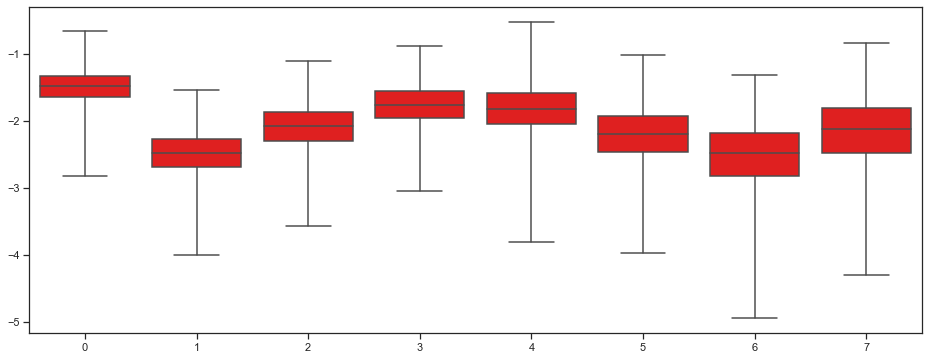

In [17]:
# A Boxplot of the Regional Distribution of observations

a4_sample = pd.DataFrame(fit_m4['alpha'])

sns.set(style="ticks", palette="muted", color_codes=True)

# Plot the orbital period with horizontal boxes
plt.figure(figsize=(16, 6))
sns.boxplot(data=a4_sample, whis=np.inf, color="red")

In [243]:
# Anova for Alphas

a4_sample.rename({0:'R1', 1:'R2', 2:'R3', 3:'R4', 4:'R5', 5:'R6', 6:'R7', 7:'R8'}, axis=1, inplace=True)
new_sample4 = pd.melt(a4_sample.reset_index(), id_vars=['index'], value_vars=['R1','R2','R3','R4','R5','R6','R7','R8'])
new_sample4.columns = ['index', 'regions', 'value']

# Fetch ANOVA table output
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Ordinary Least Squares (OLS) model
model4 = ols('value ~ C(regions)', data=new_sample4).fit()
anova_table = sm.stats.anova_lm(model4, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(regions),1815.701471,7.0,1742.66049,0.0
Residual,2380.325788,15992.0,NaN,NaN


In [238]:
#  perform Tukey's test
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=new_sample4['value'],
                          groups=new_sample4['regions'],
                          alpha=0.05)

#display results
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    R1     R2  -0.9934  0.001 -1.0304 -0.9564   True
    R1     R3  -0.5942  0.001 -0.6312 -0.5573   True
    R1     R4  -0.2668  0.001 -0.3038 -0.2298   True
    R1     R5  -0.3224  0.001 -0.3594 -0.2855   True
    R1     R6  -0.7211  0.001 -0.7581 -0.6841   True
    R1     R7  -1.0371  0.001 -1.0741 -1.0001   True
    R1     R8  -0.6652  0.001 -0.7021 -0.6282   True
    R2     R3   0.3992  0.001  0.3622  0.4362   True
    R2     R4   0.7266  0.001  0.6896  0.7636   True
    R2     R5    0.671  0.001   0.634   0.708   True
    R2     R6   0.2723  0.001  0.2353  0.3093   True
    R2     R7  -0.0437 0.0082 -0.0807 -0.0067   True
    R2     R8   0.3283  0.001  0.2913  0.3652   True
    R3     R4   0.3274  0.001  0.2905  0.3644   True
    R3     R5   0.2718  0.001  0.2348  0.3088   True
    R3     R6  -0.1269  0.001 -0.1638 -0.0899 

In [20]:
# Making Prediction With Test Data

In [239]:
# Importing The Test Data

test_dat = pd.read_csv('C:/Users/nasakyi/Desktop/Thesis/VaccTest.csv')
test_dat.head


<bound method NDFrame.head of      VaccManDat.VACC_STATUS  VaccManDat.GENDER  XG1  XG2  VaccManDat.RACE  \
0                         0                  2    0    1                1   
1                         0                  1    1    0                1   
2                         0                  2    0    1                1   
3                         0                  2    0    1                1   
4                         1                  2    0    1                4   
..                      ...                ...  ...  ...              ...   
196                       0                  2    0    1                1   
197                       0                  2    0    1                1   
198                       0                  2    0    1                1   
199                       0                  2    0    1                1   
200                       0                  1    1    0                1   

     VaccManDat.HISPANIC  VaccManDat.EDUC  XE

In [106]:
# predictors of test data

X2 = test_dat[['XG1','XE1', 'XE2', 'XE3','XIN1','XIN2']]
X2.head()

,XG1,XE1,XE2,XE3,XIN1,XIN2
0,0,0,0,1,0,0
1,1,0,0,0,0,0
2,0,0,1,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,1


In [23]:
pred_data = mod4_data.copy()
pred_data['N'] = 201 # 201 new observations to predict
pred_data['X'] = X2 # New observations
#predictions = SM_m4.generate_quantities(pred_data, fit_m4)

In [24]:
#New observation
new_x = X2

# Extract samples as a dictionary
samples = {'alpha': fit_m4['alpha'],
          'beta': fit_m4['beta']}

# Extract samples for the intercept and coefficents of the linear model
intercept_samples = samples['alpha']
coef_samples = samples['beta']

# Initialize a place to store the predictions
predictions = np.zeros_like(intercept_samples)

# Loop over each sample
#for i, (a, b) in enumerate(zip(intercept_samples.reshape(8,-1), coef_samples.reshape(6,8,-1))):
    
    # Compute the prediction manually
   # predictions[i] = a + new_x@b

In [25]:
from sklearn.metrics import classification_report

#classification_report(vacc, fit_m4['pi_hat'])

In [26]:
np.shape(coef_samples)

(2000, 6, 8)

In [28]:
#coef_samples.shape()

In [244]:
# Extract samples as a dictionary
samples = {'alpha': fit_m4['alpha'],
          'beta': fit_m4['beta']}

In [30]:
# Creating A Function that Outputs Predictions for A Region

pred = []
lpred = []
def predct(X, a, b):
    for i in range(len(X)):
        lpred[i] = a + X[i]*(b)
        pred[i] = np.exp(lpred[i])/1 + np.exp(lpred[i])
        pred.append(pred[i])
    return pred
                                

In [31]:
def predc(X, a, b):
    print(X.shape)
    print(b.shape)
    if X.shape[1] == b.shape[0]:
        #for i in range(len(X)):
        #creating empty list for the resulting vector
        results = []
        #variable for each row of action
        items = 0
        #for j in range(len(b)):
        #adding the result of matrix vector itemwise multiplication
        #print (X[i][j])
        #print (b[j])
        items += np.exp(a + np.matmul(X,b))/1 + np.exp(a + np.matmul(X,b))
        #items += np.exp(a + X[i][j] * b[j])/1 + np.exp(a + X[i][j] * b[j])
        results.append(items)
        return results

In [32]:
def predic(X, a, b):
    if X.shape[1] == b.shape[0]:
        results = []
        #variable for each row of action
        items = 0
        items += np.exp(a + np.matmul(X,b))/1 + np.exp(a + np.matmul(X,b))
        results.append(items)
        return results

In [33]:
reg_1 = X2.iloc[1:35, ]
reg_1.tail()

,XG1,XE1,XE2,XE3,XIN1,XIN2
30,0,0,0,1,1,0
31,1,0,0,0,0,0
32,0,1,0,0,0,1
33,1,0,0,0,0,0
34,0,0,0,0,0,0


In [34]:
len(reg_1)

34

In [35]:
reg_1.shape

(34, 6)

In [36]:
mod4_beta[:,0].shape;

In [37]:
mod4_alpha[0]; mod4_beta[:,0]

array([-0.00207513,  0.00310979,  0.05542378,  0.12049629,  0.03807622,
        0.01909385])

In [123]:
firstreg = np.array(predic(reg_1, mod4_alpha[0], mod4_beta[:,0])).transpose()
firstreg

array([[0.44580728],
       [0.47219199],
       [0.44673334],
       [0.45534516],
       [0.48950112],
       [0.44673334],
       [0.46310924],
       [0.5125903 ],
       [0.51365509],
       [0.44673334],
       [0.50289582],
       [0.51365509],
       [0.44580728],
       [0.47219199],
       [0.46407125],
       [0.44580728],
       [0.50394048],
       [0.51365509],
       [0.50289582],
       [0.52349861],
       [0.52241342],
       [0.45534516],
       [0.44673334],
       [0.44673334],
       [0.44673334],
       [0.44580728],
       [0.44673334],
       [0.48950112],
       [0.44673334],
       [0.52349861],
       [0.44580728],
       [0.45676339],
       [0.44580728],
       [0.44673334]])

In [122]:
type(firstreg); firstreg.shape

(1, 34)

In [40]:
reg_2 = X2.iloc[35:72, ]
len(reg_2)

37

In [225]:
reg_3 = X2.iloc[72:100, ]
reg_4 = X2.iloc[100:127, ]
reg_5 = X2.iloc[127:147, ]
reg_6 = X2.iloc[147:163, ]
reg_7 = X2.iloc[163:191, ]
reg_8 = X2.iloc[191:201, ]

In [226]:
secreg = np.array(predic(reg_2, mod4_alpha[1], mod4_beta[:,1])).transpose()
thdreg = np.array(predic(reg_3, mod4_alpha[2], mod4_beta[:,2])).transpose()
frthreg = np.array(predic(reg_4, mod4_alpha[3], mod4_beta[:,3])).transpose()
fifthtreg = np.array(predic(reg_5, mod4_alpha[4], mod4_beta[:,4])).transpose()
sixreg = np.array(predic(reg_6, mod4_alpha[5], mod4_beta[:,5])).transpose()
sevreg = np.array(predic(reg_7, mod4_alpha[6], mod4_beta[:,6])).transpose()
eghtreg = np.array(predic(reg_8, mod4_alpha[7], mod4_beta[:,7])).transpose()

In [227]:
predicted = np.vstack([firstreg,secreg,thdreg,frthreg,fifthtreg,sixreg,sevreg,eghtreg])

In [228]:
predicted

array([[0.44580728],
       [0.47219199],
       [0.44673334],
       [0.45534516],
       [0.48950112],
       [0.44673334],
       [0.46310924],
       [0.5125903 ],
       [0.51365509],
       [0.44673334],
       [0.50289582],
       [0.51365509],
       [0.44580728],
       [0.47219199],
       [0.46407125],
       [0.44580728],
       [0.50394048],
       [0.51365509],
       [0.50289582],
       [0.52349861],
       [0.52241342],
       [0.45534516],
       [0.44673334],
       [0.44673334],
       [0.44673334],
       [0.44580728],
       [0.44673334],
       [0.48950112],
       [0.44673334],
       [0.52349861],
       [0.44580728],
       [0.45676339],
       [0.44580728],
       [0.44673334],
       [0.16692783],
       [0.16543017],
       [0.16543017],
       [0.17086007],
       [0.17240689],
       [0.16543017],
       [0.17550448],
       [0.16692783],
       [0.17406251],
       [0.17550448],
       [0.17299103],
       [0.17086007],
       [0.17550448],
       [0.170

In [249]:

predicted[predicted >= 0.5] = 1

predicted[predicted < 0.5] = 0

predicted = np.array(predicted)


In [250]:
yobs = test_dat.iloc[:,0]
yobs = yobs[:-1]
actual = np.array(yobs)

In [256]:
w = predicted == yobs


In [252]:
match = w.to_frame()
match.tail()

,VaccManDat.VACC_STATUS
195,False
196,False
197,False
198,False
199,False


In [253]:
accuracy = ((actual == predicted).sum()/float(len(actual)))
accuracy

173.8

In [254]:
from sklearn.metrics import confusion_matrix
 
cm = confusion_matrix(actual,predicted)
cm

array([[172,  10],
       [ 18,   0]], dtype=int64)

In [246]:
from sklearn.metrics import classification_report
 
print(classification_report(actual,predicted))

              precision    recall  f1-score   support

           0       0.91      0.95      0.92       182
           1       0.00      0.00      0.00        18

    accuracy                           0.86       200
   macro avg       0.45      0.47      0.46       200
weighted avg       0.82      0.86      0.84       200



In [74]:
X2_new = test_dat[['XG1','XE1', 'XE2', 'XE3','XIN1','XIN2','REGCODE']]
X2_new.head

<bound method NDFrame.head of      XG1  XE1  XE2  XE3  XIN1  XIN2  REGCODE
0      0    0    0    1     0     0        1
1      1    0    0    0     0     0        1
2      0    0    1    0     0     0        1
3      0    0    0    0     0     0        1
4      0    0    0    0     0     1        1
..   ...  ...  ...  ...   ...   ...      ...
196    0    0    0    1     0     1        8
197    0    0    1    0     0     0        8
198    0    0    0    1     0     0        8
199    0    0    0    0     0     0        8
200    1    0    1    0     1     0        8

[201 rows x 7 columns]>

In [75]:
X2_new

,XG1,XE1,XE2,XE3,XIN1,XIN2,REGCODE
0,0,0,0,1,0,0,1
1,1,0,0,0,0,0,1
2,0,0,1,0,0,0,1
3,0,0,0,0,0,0,1
4,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...
196,0,0,0,1,0,1,8
197,0,0,1,0,0,0,8
198,0,0,0,1,0,0,8
199,0,0,0,0,0,0,8


In [98]:
rvec==1

0       True
1       True
2       True
3       True
4       True
       ...  
196    False
197    False
198    False
199    False
200    False
Name: REGCODE, Length: 201, dtype: bool

In [107]:
reg.dat=X2[rvec==1]

In [108]:
reg.dat

,XG1,XE1,XE2,XE3,XIN1,XIN2
0,0,0,0,1,0,0
1,1,0,0,0,0,0
2,0,0,1,0,0,0
3,0,0,0,0,0,0
4,0,0,0,0,0,1
5,1,0,1,0,1,0
6,0,0,0,0,0,0
7,1,0,0,0,1,0
8,1,0,0,1,0,1
9,0,0,0,1,0,1
